# 05 - Swing Outcomes by Pitch Type

## MLB Ballpark Effects on Pitch Type Frequency & Contact Quality

This notebook conducts **Layer 2** of the three-layer analytical framework — examining whether swing outcomes (whiff, foul, in play) differ by park and pitch type across the sample.

Whiff and foul rates are computed per park per pitch type and compared against the league-wide baseline established in `02_eda.ipynb`. Deviations from that baseline are the signal of interest here.

No contact quality data is used in this notebook — SOV and batted ball quality are examined in notebook 06.

*Sample*: 173,137 swings across 29 parks (2023–2025 pooled)
<br>
*Granularity*: Park-level swing outcomes by pitch type (Level 1 classification)
<br>
*Baseline*: League-wide whiff and foul rates from EDA

___
## 1) Setup & Data Load

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

#  Database connection 
DB_PATH = Path(r"C:\Users\Bryce Gelarden\OneDrive - Indiana University\Documents\Github - brycemgelarden\MLB_Ballpark_Factor_Analysis\database\mlb_ballpark_effects.db")

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM swings", conn)
conn.close()

#  Color scheme (project-wide) 
COLORS = {
    "Fastball":  "#1F4E79",
    "Breaking":  "#2E75B6",
    "Offspeed":  "#9DC3E6",
    "reference": "#9DC3E6",
}

#  Outcomes color scheme 
OUTCOME_COLORS = {
    "whiff":   "#C00000",
    "foul":    "#F4B942",
    "in_play": "#70AD47",
}

In [2]:
# Validation

n_rows  = len(df)
n_parks = df["home_team"].nunique()

print(f"Rows loaded:  {n_rows:,}")
print(f"Parks loaded: {n_parks}")
print(f"\nSwing outcomes present:\n{df['swing_outcome'].value_counts()}")
print(f"\nPitch categories present:\n{df['pitch_category'].value_counts()}")

Rows loaded:  173,137
Parks loaded: 29

Swing outcomes present:
swing_outcome
foul       65205
in_play    63777
whiff      44155
Name: count, dtype: int64

Pitch categories present:
pitch_category
Fastball    96689
Breaking    51650
Offspeed    24798
Name: count, dtype: int64


___
## 2) League-Wide Baseline (Whiff, Foul, In-Play)

Baseline swing outcome rates are established here from the pooled sample 
(`02_eda.ipynb`) and serve as the reference point for all park-level 
deviation analysis in Sections 3–6.

In [3]:
# Overall Baseline

overall_baseline = (
    df["swing_outcome"]
    .value_counts(normalize=True)
    .reindex(["whiff", "foul", "in_play"]) * 100
)

print(f"League-Wide Swing Outcomes  (n = {len(df):,})\n")
print(overall_baseline.round(2).to_string())

League-Wide Swing Outcomes  (n = 173,137)

swing_outcome
whiff      25.50
foul       37.66
in_play    36.84


In [ ]:
# Baseline by Pitch Category

category_baseline = (
    df.groupby("pitch_category")["swing_outcome"]
    .value_counts(normalize=True)
    .unstack() * 100
)[["whiff", "foul", "in_play"]].loc[["Fastball", "Breaking", "Offspeed"]]

print(f"Swing Outcomes by Pitch Category  (n = {len(df):,})\n")
print(category_baseline.round(2).to_string())

Swing Outcomes by Pitch Category  (n = 173,137)

swing_outcome   whiff   foul  in_play
pitch_category                       
Fastball        20.16  42.20    37.65
Breaking        32.64  32.48    34.88
Offspeed        31.47  30.77    37.76


*For visual reference, see `02_eda.ipynb` Section 4 (Swing Outcome Distribution).*


___
## 3) Park-Level Outcome Rates (Overall)

In [7]:
# Overall whiff/foul/in_play rates per park across all pitch types (table)

park_outcomes = (
    df.groupby(["home_team", "swing_outcome"])
    .size()
    .unstack(fill_value=0)
)[["whiff", "foul", "in_play"]]

park_n = park_outcomes.sum(axis=1).rename("n")
park_outcome_rates = park_outcomes.div(park_n, axis=0) * 100
park_outcome_rates.insert(0, "n", park_n)

print(f"Park-Level Swing Outcome Rates  (n per park ≈ 5,970)\n")
print(park_outcome_rates.sort_values("whiff", ascending=False).round(2).to_string())

Park-Level Swing Outcome Rates  (n per park ≈ 5,970)

swing_outcome     n  whiff   foul  in_play
home_team                                 
SEA            5944  28.55  37.63    33.82
ATL            5927  28.06  37.20    34.74
LAA            5973  27.69  37.05    35.26
HOU            5978  27.57  35.90    36.53
NYM            5998  27.13  37.83    35.05
NYY            5999  27.05  37.72    35.22
TB             5981  27.05  38.09    34.86
DET            5965  26.35  36.56    37.08
CWS            5964  26.19  37.81    36.00
PHI            5993  26.08  38.93    34.99
TEX            5990  25.94  37.83    36.23
MIN            6000  25.88  38.43    35.68
MIA            5998  25.66  37.08    37.26
LAD            5988  25.58  38.54    35.87
PIT            6000  25.47  35.97    38.57
MIL            5903  25.33  38.35    36.32
BAL            5957  25.30  38.26    36.44
CIN            5953  25.10  37.73    37.17
SF             5966  24.91  36.57    38.52
COL            5994  24.84  36.35    38.81


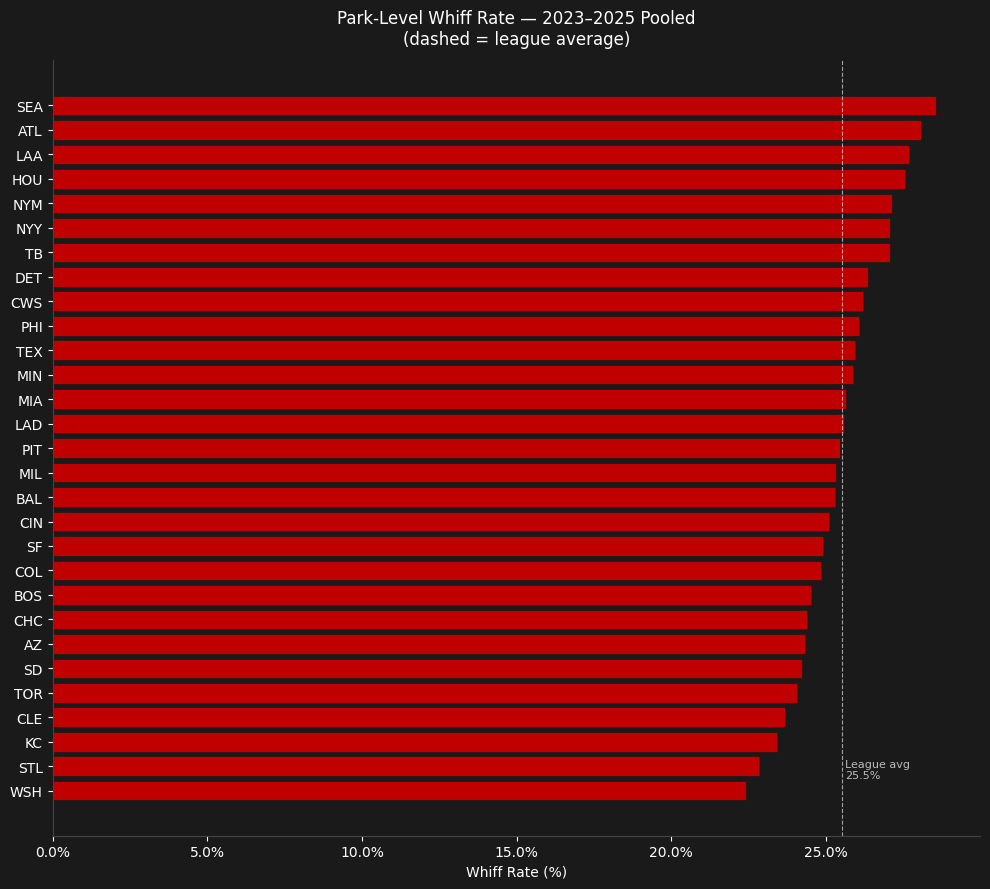

In [ ]:
# visualizing whiff rate at each park w/o pitch types

whiff_sorted = park_outcome_rates.sort_values("whiff", ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))

bars = ax.barh(
    whiff_sorted.index,
    whiff_sorted["whiff"],
    color=OUTCOME_COLORS["whiff"],
    edgecolor="#1a1a1a",
    linewidth=0.5,
)

# reference line of league average (whiff rate) 
league_whiff = overall_baseline["whiff"]
ax.axvline(league_whiff, color="white", linewidth=0.8, linestyle="--", alpha=0.6)
ax.text(league_whiff + 0.1, 0.5, f"League avg\n{league_whiff:.1f}%", 
        color="white", fontsize=8, alpha=0.7)

ax.set_title("Park-Level Whiff Rate — 2023–2025 Pooled\n(dashed = league average)",
             color="white", fontsize=12, pad=12)
ax.set_xlabel("Whiff Rate (%)", color="white")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

ax.set_facecolor("#1a1a1a")
fig.patch.set_facecolor("#1a1a1a")
ax.tick_params(colors="white")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#444444")

plt.tight_layout()
plt.show()

**SEA leads the sample in whiff rate by a considerable margin** which is consistent with the Mariners' identity as both a swing-and-miss pitching staff and a high-strikeout offensive environment. Also worth noting park-level whiff rates reflect both teams in every game, meaning teams' pitching and hitting tendencies are embedded in these numbers alongside any park effects.

**STL and WSH sit at the bottom of the whiff rate distribution** — and for STL, this is not surprising in context. `Notebook 04` established Busch Stadium a heavy sinker environment with an active FF → SI substitution pattern. Sinkers are not swing-and-miss pitches but weak contact pitches. Low whiff rate at Busch is the intended outcome of the pitching approach the data is reveals. This thread will be tested directly in `Notebook 06` when SOV brings the contact quality layer into focus.

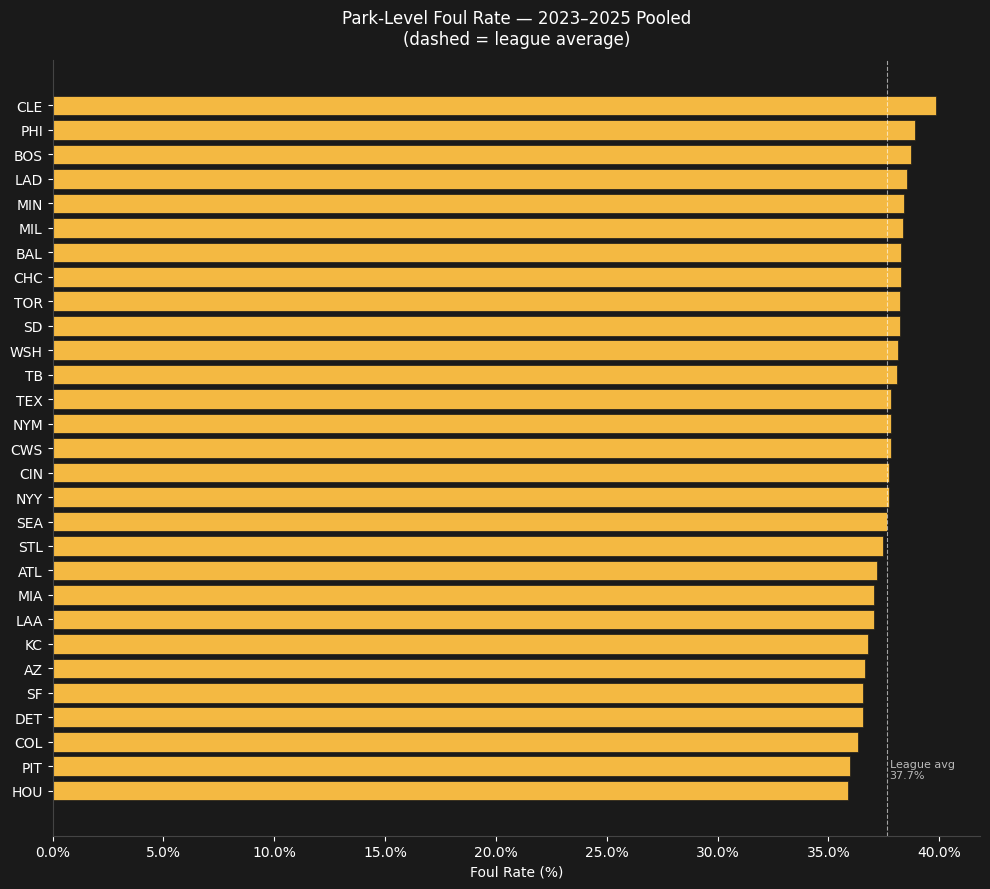

In [ ]:
# Visualizing foul rate at each park w/o pitch types

foul_sorted = park_outcome_rates.sort_values("foul", ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))

ax.barh(
    foul_sorted.index,
    foul_sorted["foul"],
    color=OUTCOME_COLORS["foul"],
    edgecolor="#1a1a1a",
    linewidth=0.5,
)

league_foul = overall_baseline["foul"]
ax.axvline(league_foul, color="white", linewidth=0.8, linestyle="--", alpha=0.6)
ax.text(league_foul + 0.1, 0.5, f"League avg\n{league_foul:.1f}%",
        color="white", fontsize=8, alpha=0.7)

ax.set_title("Park-Level Foul Rate — 2023–2025 Pooled\n(dashed = league average)",
             color="white", fontsize=12, pad=12)
ax.set_xlabel("Foul Rate (%)", color="white")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

ax.set_facecolor("#1a1a1a")
fig.patch.set_facecolor("#1a1a1a")
ax.tick_params(colors="white")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#444444")

plt.tight_layout()
plt.show()

Yellow chart above denotes the foul rates at each park, by process of elimination, we know which park has the highest in_play rate.  
<br>
Instead of showing that individually, a stacked bar chart is shown below:

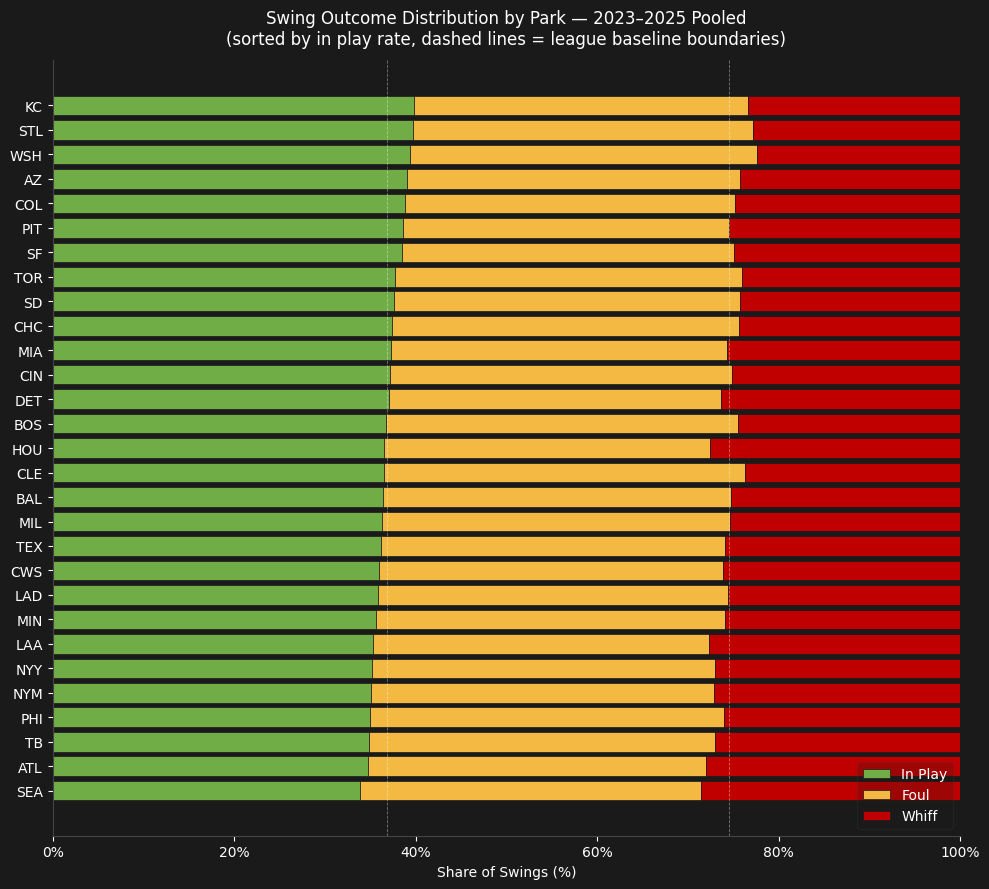

In [10]:
# sort by in_play rate descending — highest in_play parks on top
outcome_sorted = park_outcome_rates.sort_values("in_play", ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))

left = np.zeros(len(outcome_sorted))
for outcome in ["in_play", "foul", "whiff"]:
    values = outcome_sorted[outcome].values
    ax.barh(
        outcome_sorted.index,
        values,
        left=left,
        color=OUTCOME_COLORS[outcome],
        label=outcome.replace("_", " ").title(),
        edgecolor="#1a1a1a",
        linewidth=0.5,
    )
    left += values

# league average boundary reference lines
cumulative = 0
for outcome in ["in_play", "foul"]:
    cumulative += overall_baseline[outcome]
    ax.axvline(cumulative, color="white", linewidth=0.6, linestyle="--", alpha=0.4)

ax.set_xlabel("Share of Swings (%)", color="white")
ax.set_title("Swing Outcome Distribution by Park — 2023–2025 Pooled\n(sorted by in play rate, dashed lines = league baseline boundaries)",
             color="white", fontsize=12, pad=12)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 100)

ax.set_facecolor("#1a1a1a")
fig.patch.set_facecolor("#1a1a1a")
ax.tick_params(colors="white")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#444444")

ax.legend(
    loc="lower right",
    framealpha=0.2,
    labelcolor="white",
    facecolor="#1a1a1a",
    edgecolor="#444444",
)

plt.tight_layout()
plt.show()

___
## 4) Park-Level Outcome Rates by Pitch Type

___
## 5) Deviation from Baseline

___
## 6) Statistical Significance

___
## 7) Observations & Forward Look